In [196]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import json
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

ATTACK_METHOD = "deepfool"  # Change to "pgd" or other methods
DATASET_NAME = "taiwan_bankruptcy"
ALPHA = 0.001
EPSILON = 0.02
MAXITERS = 500
ATTACK_PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
K_RANKS = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]

# DATA_DIR = Path('spambase_50_50')
if DATASET_NAME == "spambase":
    DATA_DIR = Path('/home/skada009/aro/spambase_10_40_50')
    SCORES_DIR = Path('/home/skada009/aro/experiments/noise_scoring_outputs/20260324_203954')
    
    MLP = 'spambase_mlp.pth'
else:
    DATA_DIR = Path('/home/skada009/aro/taiwan_bankruptcy_10_40_50')
    SCORES_DIR = Path('/home/skada009/aro/experiments/noise_scoring_outputs/taiwan_bankruptcy/20260514_161236')
    MLP = 'taiwan_bankruptcy_mlp.pth'

if ATTACK_METHOD == "pgd" or ATTACK_METHOD == "fgsm":
    OUTPUT_DIR = Path(f'/home/skada009/aro/final_notebooks/results/{DATASET_NAME}/{ATTACK_METHOD}_{EPSILON}')
    PREV_RESULTS_DIR = Path(f'/home/skada009/aro/final_notebooks/results/{DATASET_NAME}/{ATTACK_METHOD}_{EPSILON}')
elif ATTACK_METHOD == "deepfool":
    OUTPUT_DIR = Path(f'/home/skada009/aro/final_notebooks/results/{DATASET_NAME}/{ATTACK_METHOD}_{ALPHA}')
    PREV_RESULTS_DIR = Path(f'/home/skada009/aro/final_notebooks/results/{DATASET_NAME}/{ATTACK_METHOD}_{ALPHA}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda
GPU: NVIDIA RTX A6000


In [197]:
data = np.load(DATA_DIR / 'train_test_data.npz')
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test']
n_test, n_features = X_test.shape
n_svd_basis_rows = int(data['X_svd'].shape[0])

prep = np.load(DATA_DIR / 'preprocessing.npz')
weights = prep['weights']
bounds = [prep['bounds_min'], prep['bounds_max']]


class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)

class BankruptcyNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)
    
checkpoint = torch.load(DATA_DIR / MLP, map_location=device)
if DATASET_NAME == "spambase":
    model = SpambaseNet(D_in=57).to(device)
else:
    model = BankruptcyNet(checkpoint['D_in']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
X_test_t = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)
print(f'SVD basis partition: {n_svd_basis_rows} samples (see clean_svd_basis.npz)')
print(f'Test set: {n_test} samples, {n_features} features')
print(f'Correctly classified: {n_correct}/{n_test} ({n_correct/n_test:.2%})')

print(f"✓ Model loaded | Train Acc: {checkpoint.get('train_accuracy', 'N/A')}, Test Acc: {checkpoint.get('test_accuracy', 'N/A')}")

print("Loading test data...")
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test'].astype(np.int64)
print(f"✓ Test set: {X_test.shape}")

print("Loading preprocessing parameters...")
weights = prep['weights'].astype(np.float32)
bounds_min = prep['bounds_min'].astype(np.float32)
bounds_max = prep['bounds_max'].astype(np.float32)
bounds = [bounds_min, bounds_max]
print(f"✓ Bounds: [{bounds_min.min():.4f}, {bounds_max.max():.4f}], Weights shape: {weights.shape}")


SVD basis partition: 682 samples (see clean_svd_basis.npz)
Test set: 3410 samples, 94 features
Correctly classified: 2998/3410 (87.92%)
✓ Model loaded | Train Acc: 0.8888888888888888, Test Acc: 0.8791788856304985
Loading test data...
✓ Test set: (3410, 94)
Loading preprocessing parameters...
✓ Bounds: [0.0000, 1.0000], Weights shape: (94,)


In [198]:


score1_removal_order = np.load('/home/skada009/aro/experiments/noise_scoring_outputs/20260324_203954/test_clean_data_score1_removed_index.npy').astype(int)
score2_value = np.load('/home/skada009/aro/experiments/noise_scoring_outputs/20260324_203954/test_clean_data_score2_noise_scores.npy')

# Noisiest-first orderings, filtered to correctly-classified only
score1_order = [idx for idx in score1_removal_order if correct_mask[idx]]
score2_order = [idx for idx in np.argsort(score2_value)[::-1] if correct_mask[idx]]

score_orders = {'Score 1': score1_order, 'Score 2': score2_order}
print(f'Eligible points per score ordering: {len(score1_order)}')

Eligible points per score ordering: 2033


In [199]:
svd_basis = np.load(DATA_DIR / 'clean_svd_basis.npz')
Vt_clean = svd_basis['Vt_svd'].astype(np.float32)
S_clean = svd_basis['S_svd']
print(f'Clean basis shape: Vt_clean = {Vt_clean.shape} (SVD rows = {n_svd_basis_rows})')
print(f'Top-10 singular values: {S_clean[:10].round(2)}')
print(f'Cumulative energy at each k:')
cumvar = np.cumsum(S_clean**2) / np.sum(S_clean**2)
for k in K_RANKS:
    print(f'  k={k:>2d}: {cumvar[k-1]:.4f}')

Clean basis shape: Vt_clean = (94, 94) (SVD rows = 682)
Top-10 singular values: [110.43  10.73   9.91   9.14   7.59   7.3    7.23   6.3    6.12   5.8 ]
Cumulative energy at each k:
  k= 1: 0.9477
  k= 2: 0.9566
  k= 3: 0.9642
  k= 5: 0.9752
  k=10: 0.9920
  k=15: 0.9973
  k=20: 0.9989
  k=30: 0.9998
  k=40: 1.0000
  k=50: 1.0000
  k=57: 1.0000


In [200]:
# Import attack methods
from utils.fgsm import create_fgsm, fgsm_attack

# Create attack instance
if ATTACK_METHOD == "fgsm":
    print(f"Creating FGSM attack with eps={EPSILON}...")
    wrapped_model, attack_obj = create_fgsm(model, bounds_min, bounds_max, maxiters=MAXITERS, eps=EPSILON)
    attack_func = fgsm_attack
    
elif ATTACK_METHOD == "pgd":
    print(f"Creating PGD attack with eps={EPSILON}...")
    from utils.pgd_attack import create_pgd, pgd_attack
    wrapped_model, attack_obj = create_pgd(model, bounds_min, bounds_max, max_iter=MAXITERS, eps=EPSILON)
    attack_func = pgd_attack
elif ATTACK_METHOD == "deepfool":
    from utils.deepfool import deepfool
    wrapped_model, attack_obj = None, None
    print(ALPHA)
    def deepfool_attack(x_sample, model, _attack_obj, device):
        # deepfool expects a torch Tensor sample
        x_t = torch.FloatTensor(x_sample).to(device)
        y_orig, y_adv, x_adv, _ = deepfool(
            x_t, model,
            maxiters=MAXITERS, alpha=ALPHA,
            bounds=bounds, weights=[],
        )
        return int(y_orig), int(y_adv), x_adv

    attack_func = deepfool_attack

else:
    raise ValueError(f"Unknown ATTACK_METHOD={ATTACK_METHOD!r}")

print(f"✓ Attack method: {ATTACK_METHOD.upper()}")


0.001
✓ Attack method: DEEPFOOL


In [201]:


adv_file = PREV_RESULTS_DIR / 'adversarial_samples.npz'
assert adv_file.exists(), f'Run targeted_vaccination_by_tier_{ATTACK_METHOD}.ipynb first to generate {adv_file}'

adv_data = np.load(adv_file)
X_adv = adv_data['X_adv_' + ATTACK_METHOD]
attack_success = adv_data['success_' + ATTACK_METHOD]

n_succ = attack_success[correct_indices].sum()
print(f'{ATTACK_METHOD}: {n_succ}/{n_correct} ({n_succ/n_correct:.2%}) attacks succeeded')


deepfool: 2959/2998 (98.70%) attacks succeeded


In [202]:
rows = []
t_total = time.time()

for score_name, order in score_orders.items():
    n_eligible = len(order)
    for attack_pct in ATTACK_PCTS:
        n_attack = max(1, int(n_eligible * attack_pct / 100))

        noisy_indices = order[:n_attack]
        structural_indices = order[-n_attack:]

        for tier_name, tier_idx in [('structural', structural_indices), ('noisy', noisy_indices)]:
            X_mixed = np.copy(X_test)
            n_successfully_attacked = 0
            for idx in tier_idx:
                if attack_success[idx]:
                    X_mixed[idx] = X_adv[idx]
                    n_successfully_attacked += 1

            # Calculate ASR before vaccination
            asr_before = n_successfully_attacked / len(tier_idx) if len(tier_idx) > 0 else 0.0

            if n_successfully_attacked == 0:
                for k in K_RANKS:
                    rows.append({
                        'score_type': score_name, 'tier': tier_name,
                        'attack_pct': attack_pct, 'k': k,
                        'n_targeted': len(tier_idx), 'n_attacked': 0,
                        'restoration_rate': 0.0, 'asr_after': 0.0,
                        'asr_before': asr_before,
                    })
                continue

            for k in K_RANKS:
                # Project onto precomputed clean basis instead of computing SVD on X_mixed
                Vk = Vt_clean[:k, :]  # (k, 57)
                X_vacc = (X_mixed @ Vk.T) @ Vk  # project and reconstruct
                X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)

                with torch.no_grad():
                    preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()

                n_restored = sum(
                    1 for idx in tier_idx
                    if attack_success[idx] and preds[idx] == y_test[idx]
                )
                restoration_rate = n_restored / n_successfully_attacked

                rows.append({
                    'score_type': score_name, 'tier': tier_name,
                    'attack_pct': attack_pct, 'k': k,
                    'n_targeted': len(tier_idx), 'n_attacked': n_successfully_attacked,
                    'restoration_rate': restoration_rate, 'asr_after': 1 - restoration_rate,
                    'asr_before': asr_before,
                })

        print(f'{score_name} | attack_pct={attack_pct:>3d}% done ({time.time()-t_total:.1f}s)')

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / 'vaccination_sweep.csv', index=False)
print(f'\nSweep complete: {len(df)} rows, saved to {OUTPUT_DIR / "vaccination_sweep.csv"}')
print(OUTPUT_DIR)


Score 1 | attack_pct= 10% done (0.4s)
Score 1 | attack_pct= 20% done (0.9s)
Score 1 | attack_pct= 30% done (1.5s)
Score 1 | attack_pct= 40% done (2.4s)
Score 1 | attack_pct= 50% done (2.8s)
Score 1 | attack_pct= 60% done (3.2s)
Score 1 | attack_pct= 70% done (3.5s)
Score 1 | attack_pct= 80% done (4.0s)
Score 1 | attack_pct= 90% done (4.4s)
Score 1 | attack_pct=100% done (4.8s)
Score 2 | attack_pct= 10% done (5.7s)
Score 2 | attack_pct= 20% done (6.6s)
Score 2 | attack_pct= 30% done (7.2s)
Score 2 | attack_pct= 40% done (7.8s)
Score 2 | attack_pct= 50% done (8.3s)
Score 2 | attack_pct= 60% done (8.9s)
Score 2 | attack_pct= 70% done (9.7s)
Score 2 | attack_pct= 80% done (10.4s)
Score 2 | attack_pct= 90% done (11.0s)
Score 2 | attack_pct=100% done (11.5s)

Sweep complete: 440 rows, saved to /home/skada009/aro/final_notebooks/results/taiwan_bankruptcy/deepfool_0.001/vaccination_sweep.csv
/home/skada009/aro/final_notebooks/results/taiwan_bankruptcy/deepfool_0.001


/home/skada009/aro/final_notebooks/results/taiwan_bankruptcy/deepfool_0.001
Saved vaccination_clean_score1_structural.png


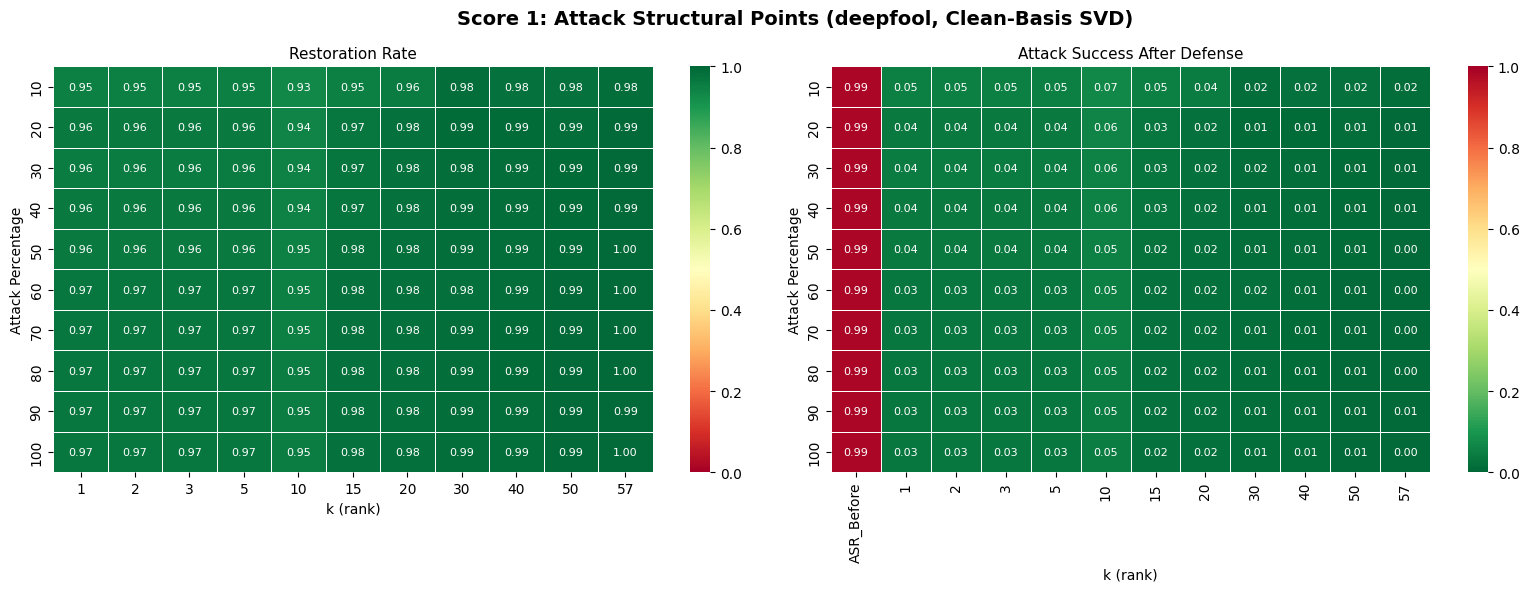

/home/skada009/aro/final_notebooks/results/taiwan_bankruptcy/deepfool_0.001
Saved vaccination_clean_score1_noisy.png


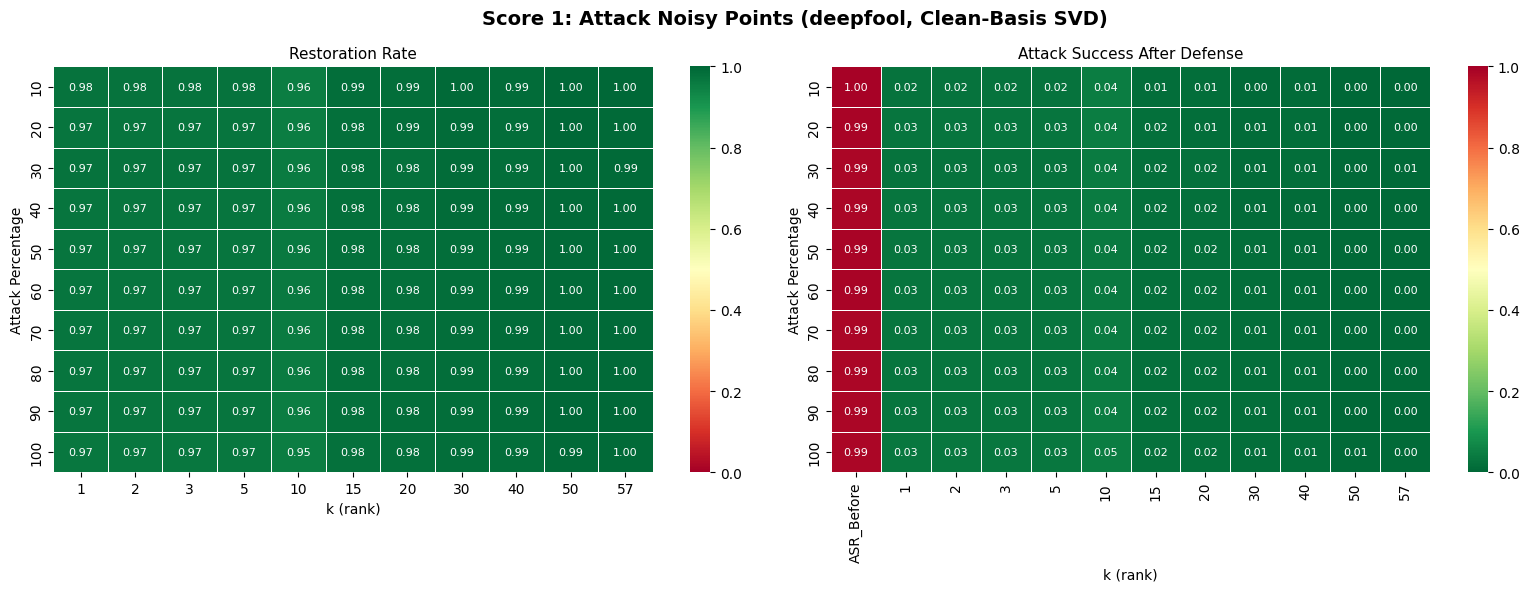

/home/skada009/aro/final_notebooks/results/taiwan_bankruptcy/deepfool_0.001
Saved vaccination_clean_score2_structural.png


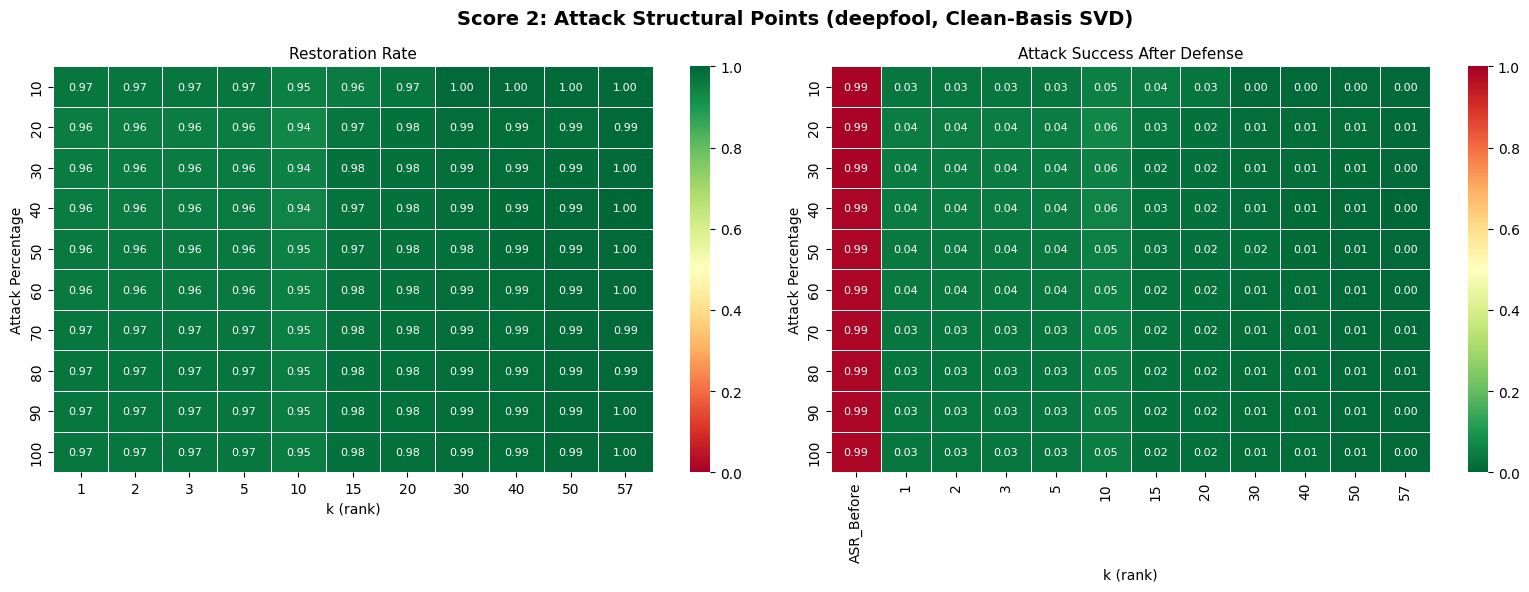

/home/skada009/aro/final_notebooks/results/taiwan_bankruptcy/deepfool_0.001
Saved vaccination_clean_score2_noisy.png


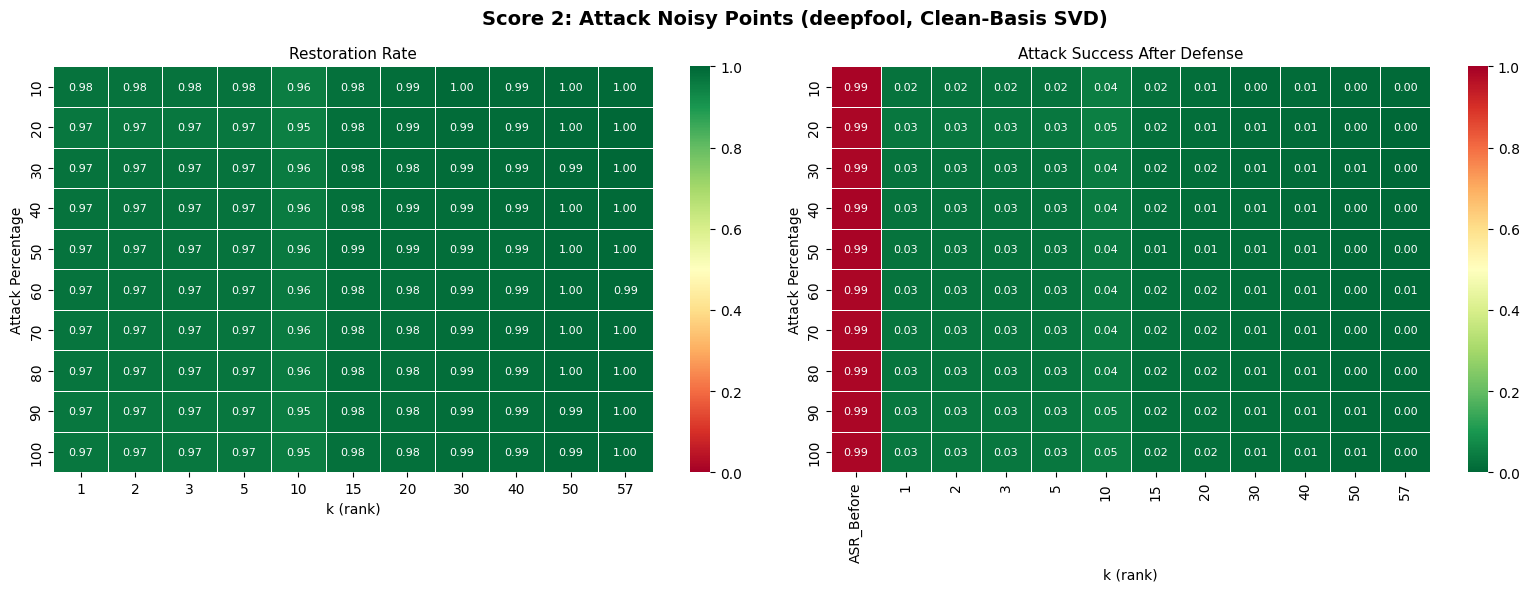

In [203]:
def plot_vaccination_heatmaps(df, score_name, tier_name, output_dir):
    print(output_dir)
    sub = df[(df['score_type'] == score_name) & (df['tier'] == tier_name)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f'{score_name}: Attack {tier_name.capitalize()} Points ({ATTACK_METHOD}, Clean-Basis SVD)',
        fontsize=14, fontweight='bold',
    )

    # Get ASR before vaccination
    asr_before_values = sub.groupby('attack_pct')['asr_before'].first()

    # Restoration rate heatmap with ASR before as first column
    pivot_rest = sub.pivot(index='attack_pct', columns='k', values='restoration_rate')
    pivot_rest = pivot_rest.sort_index(ascending=True)
    pivot_rest_with_asr = pivot_rest.copy()
    # pivot_rest_with_asr.insert(0, 'ASR_Before', [asr_before_values[pct] for pct in pivot_rest_with_asr.index])

    sns.heatmap(
        pivot_rest_with_asr, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=0, vmax=1, linewidths=0.5,
        annot_kws={'size': 8},
    )
    axes[0].set_title('Restoration Rate', fontsize=11)
    axes[0].set_xlabel('k (rank)')
    axes[0].set_ylabel('Attack Percentage')

    # Attack success after defense heatmap with ASR before as first column
    pivot_asr = sub.pivot(index='attack_pct', columns='k', values='asr_after')
    pivot_asr = pivot_asr.sort_index(ascending=True)
    pivot_asr_with_asr = pivot_asr.copy()
    pivot_asr_with_asr.insert(0, 'ASR_Before', [asr_before_values[pct] for pct in pivot_asr_with_asr.index])

    sns.heatmap(
        pivot_asr_with_asr, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn_r',
        vmin=0, vmax=1, linewidths=0.5,
        annot_kws={'size': 8},
    )
    axes[1].set_title('Attack Success After Defense', fontsize=11)
    axes[1].set_xlabel('k (rank)')
    axes[1].set_ylabel('Attack Percentage')

    plt.tight_layout()
    fname = f'vaccination_clean_{score_name.lower().replace(" ", "")}_{tier_name}.png'
    fig.savefig(output_dir / fname, dpi=150, bbox_inches='tight')
    print(f'Saved {fname}')
    plt.show()


for score_name in score_orders:
    for tier_name in ['structural', 'noisy']:
        plot_vaccination_heatmaps(df, score_name, tier_name, OUTPUT_DIR)
